# **Exploratory Data Analysis. Netflix**

##**Обзор данных**

**Импортируем все библиотеки, с которыми будем работать:**

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

In [ ]:
%matplotlib inline

Прежде чем приступить к очистке, изучению и анализу данных, необходимо уделить время их источнику. Был дан датасет `1000 Netflix Shows`. В данном случае выборкой являются 1000 наблюдений, представленных в датасете. Также важно учесть временной аспект, ведь датасет отражает состояние каталога Netflix на 11.06.2017.

На этапе получения и обзора данных важно определить, откуда берутся данные, с какой целью их собирали. Также важно проверить их качество, оценить объем и репрезентативность. При наличии отразить источники искажений, которые могли возникнуть даже уже в процессе отбора этих данных. Упомянем основные моменты:


- Данные, представленные в данном датасете, скорее всего были собраны и опубликованы пользователями на таких платформах, как [Kaggle](https://www.kaggle.com/datasets/chasewillden/netflix-shows). Пользователи получали их через общедоступные источники путем парсинга, обзора страниц Netflix, какие-то открытые базы данных о фильмах и шоу. То есть, этот датасет не является официальным от самой компании Netflix.
- Источниками искажения могут служить региональные различия, по типу наличие контента одной страны может не совпадать с наличием в другой. Также напоминаем про временной аспект, изменения каталога после 2017 не учитываются. Помимо того, так как данные собирались посторонними, есть вероятность ошибок, неполноты данных.
- Сам автор датасета, похожего на наш, пишет, что в качестве метода сбора данных использовал систему рекомендаций Netflix. Процитируем его: "Because of the vast amount of time it would take to gather 1,000 shows one by one, the gathering method took advantage of the Netflix’s suggestion engine. The suggestion engine recommends shows similar to the selected show. As part of this data set, I took 4 videos from 4 ratings (totaling 16 unique shows), then pulled 53 suggested shows per video. The ratings include: G, PG, TV-14, TV-MA. I chose not to pull from every rating (e.g. TV-G, TV-Y, etc.)." То есть он сначала взял 4 видео, по 1 из каждой из 4 категорий рейтинга и затем получал по 53 рекомендуемых шоу для каждого из них. Для нас это значит, что данные были получены скорее не случайным образом, а через рекомендации пользователя. Это может повлиять на репрезентативность данных и разнообразие контента. Данные могут быть смещены в сторону в более популярных и рекомендованных шоу, например. Также из-за такой цепочки действий шоу могли повторяться, рейтинги могли включать доп. категории. Все это приводит к тому, что нам нужно быть предельно внимательными и при предобработке данных, и при выявлении закономерностей, и при формировании выводов.
- Цель такого датасета и ему подобных заключается чаще всего просто в предоставлении данных для общего анализа и использования в учебных и аналитических проектах.

**Прочитаем данные нашего датасета, посмотрим на его состав, несколько наблюдений, форму, количество дубликатов и пропусков:**

In [ ]:
netflix_shows = pd.read_excel('NetflixShows.xlsx')

In [ ]:
netflix_shows.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   title              1000 non-null   object 
 1   rating             1000 non-null   object 
 2   ratingLevel        941 non-null    object 
 3   ratingDescription  1000 non-null   int64  
 4   release year       1000 non-null   int64  
 5   user rating score  605 non-null    float64
 6   user rating size   1000 non-null   int64  
dtypes: float64(1), int64(3), object(3)
memory usage: 54.8+ KB


In [ ]:
netflix_shows.head()

,title,rating,ratingLevel,ratingDescription,release year,user rating score,user rating size
0,White Chicks,PG-13,"crude and sexual humor, language and some drug...",80,2004,82.0,80
1,Lucky Number Slevin,R,"strong violence, sexual content and adult lang...",100,2006,NaN,82
2,Grey's Anatomy,TV-14,Parents strongly cautioned. May be unsuitable ...,90,2016,98.0,80
3,Prison Break,TV-14,Parents strongly cautioned. May be unsuitable ...,90,2008,98.0,80
4,How I Met Your Mother,TV-PG,Parental guidance suggested. May not be suitab...,70,2014,94.0,80


In [ ]:
netflix_shows.shape

(1000, 7)

In [ ]:
netflix_shows.describe(include='all')

,title,rating,ratingLevel,ratingDescription,release year,user rating score,user rating size
count,1000,1000,941,1000.00000,1000.000000,605.000000,1000.000000
unique,496,13,99,NaN,NaN,NaN,NaN
top,13 Reasons Why,TV-14,Parents strongly cautioned. May be unsuitable ...,NaN,NaN,NaN,NaN
freq,8,234,224,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,67.36600,2010.335000,84.094215,80.783000
std,NaN,NaN,NaN,30.78561,8.877927,12.344371,0.973066
min,NaN,NaN,NaN,10.00000,1940.000000,55.000000,80.000000
25%,NaN,NaN,NaN,35.00000,2007.000000,75.000000,80.000000
50%,NaN,NaN,NaN,60.00000,2015.000000,88.000000,80.000000
75%,NaN,NaN,NaN,90.00000,2016.000000,95.000000,82.000000


In [ ]:
netflix_shows['user rating score'].unique()

array([82., nan, 98., 94., 95., 97., 91., 96., 77., 88., 80., 74., 81.,
       57., 84., 83., 99., 89., 92., 62., 90., 79., 93., 61., 78., 66.,
       75., 63., 68., 71., 59., 73., 86., 69., 58., 55., 56., 64., 85.,
       70., 67., 72., 65.])

In [ ]:
netflix_shows['user rating size'].unique()

array([80, 82, 81])

In [ ]:
print('Количество дубликатов:')
netflix_shows.duplicated().sum()

Количество дубликатов:


np.int64(500)

In [ ]:
print('Количество пропусков в каждом столбце:')
netflix_shows.isna().sum()

Количество пропусков в каждом столбце:


,0
title,0
rating,0
ratingLevel,59
ratingDescription,0
release year,0
user rating score,395
user rating size,0


###**Возникают вопросы, как работает система рекомендаций у Netflix**

Наткнулась на [статью](https://www.teenvogue.com/story/netflix-removes-stars-replaces-thumbs-metric). Цитирую "Netflix is officially ditching its much maligned and often misunderstood stars ratings system. The metric, which rated content based on its anticipated appeal to individual users — NOT based on an average of all ratings or based on what critics thought — is being replaced by a new thumbs model that the streaming service hopes will be easier to understand." Для нас это значит, что что Netflix отказался от традиционной системы рейтингов "звезды" и заменил ее на модель "пальцев вверх/пальцев вниз". То есть, была какая-то другая система. Углубившись в статьи и новости (ссылки в доп.источниках внизу), обнаружила следующее:
- Рейтинг, который мы видим в данных, не является каким-то традиционным рейтингом. Netflix использовал модель, в которой контент оценивается на основе похожести с предпочтениями пользователя, а не как среднее значение оценок от всех пользователей.


### **Описание признаков**

|Признак|Описание|Тип признака (тип хранения)|Доп.рассуждения|
|-------|-----|------------|------------|
|title|Название шоу|Категориальный, номинальный (строка)|Определив метод сбора данных датасета,<br>помним про возможность дубликатов или даже опечаток|
|rating|Возрастной рейтинг шоу|Категориальный, номинальный (строка)|Стоит посмотреть на то, какие возрастные категории преобладают.<br> Выделить каким возрастным ограничениям соответствуют маркировки рейтинга.|
|ratingLevel|Описание рейтинговой группы и особенностей шоу<br>(дают рекомендации по возрастной категории)|Категориальный, номинальный (строка)|Можно в дальнейшем подумать про потенциальный порядок уровней,<br>то есть переход в порядковый тип признака.<br>Возможно придется стандартизировать. <br>Нужно будет подумать про корректное заполнение пропусков|
|ratingDescription|Возрастной рейтинг шоу, закодированный числом|Количественный, дискретный (целое число)|Числовой код рейтинга. Необходимо проверить логику кодирования - <br>соответствует ли большие числа "более взрослому" контенту.|
|release year|Год выпуска шоу|Количественный, дискретный (целое число)|Можно подумать про преобразование в какие-нибудь категории, чтобы проанализировать тренды|
|user rating score|Было написано: оценка пользователей<br>но не является классическим рейтингом.Это персонализированная рекомендательные контента,<br>которая может зависеть от предпочтений каждого отдельного пользователя,<br>а не от агрегированных данных.|Количественный, непрерывный (дробное число)|Нужно будет подумать про корректное заполнение пропусков|
|user rating size|В задании написано, что это общий рейтинг пользователей. <br>Кодирование взаимодействия пользователя с контентом.|Количественный, дискретный (целое число)|Зависит от действий пользователя|


### **Промежуточные выводы, которые можно сделать, глядя на выведенный результат**

- Хочется задать вопрос и сразу на него ответить. Что в данном датасете, в названиях подразумевается под шоу: шоу, сериал или фильм, или и то и другое? Посмотрев на известные названия в колонке `title` мы нашли и фильмы, и сериалы. Возможно, в дальнейшем это понимание понадобится нам для классификации шоу в категории.
- Таблица содержит 1000 строк и 7 столбцов. Каждая строка представляет определенный контент, на первый взгляд. Столбцы включают названия шоу, рейтинг, уровень рейтинга и описание, закодированное числовое значение рейтинга, год выпуска, оценка пользователей, общее количество польозвателей, поставивших рейтинг.
- В данных мы также нашли дубликаты, как и предполагалось, что это скорее всего из-за метода сбора данных появились повторяющиеся записи. Их целых 500 штук. А количетсво уникальных значений в столбце `title` равно 496.
- Пропущенные значения наблюдаются в столбцах `ratingLevel`, `user rating score`. Нужно будет обратить на них внимание при предобработке.
- Также названия колонок содержат пробелы, разный регистр. Перепишем названия столбцов в привычном и удобном для нас змеином регистре.
- Столбец `rating` содержит 13 уникальных значений. Это выходит за рамки заявленных автором датасета 4 рейтингов. Это может быть связано опять же с методом сбора данных, то бишь с использованием рекомендательной системы. Это молго привести к появлению доп. категорий.
- Глядя на статистические данные по числовым признакам, заметим, что год выпуска варьируется от 1940 года до 2017, есть и старый, и новый контент. Возможно, придется делить и изучить, как менялись предпочтения аудитории со временем.

##**Предобработка данных**

Конечно первично обработаем наш датасет, чтобы снизить риск пропустить проблемные данные. Отнесемся скурпулезно к имеющимся данным .

### **Стандартизируем для начала названия столбцов:**

In [ ]:
netflix_shows.columns = ['title', 'rating', 'rating_level', 'rating_description', 'release_year', 'user_rating_score', 'user_rating_size']
netflix_shows.columns

Index(['title', 'rating', 'rating_level', 'rating_description', 'release_year',
       'user_rating_score', 'user_rating_size'],
      dtype='object')

### **Поработаем с дубликатами в нашем датасете:**

Посмотрим, какие шоу рекомендательная система чаще всего выдавала:

In [ ]:
duplicates_count = netflix_shows[netflix_shows.duplicated(keep=False)]['title'].value_counts()
duplicates_count

,count
title,
13 Reasons Why,8
Prison Break,7
Girlboss,7
Grey's Anatomy,6
Shameless (U.S.),6
...,...
Pound Puppies,2
Ribbit,2
My Animal Friends,2


Мы видим, что система рекомендаций выдавала несколько шоу многократно. Теперь есть два варианта событий: либо это чистые явные дубликаты и мы их просто удаляем, либо могут быть разные сезоны одного и того же шоу и нужно будет их учесть. Давайте проверим это

Посмотрим на дубликаты по году и названию шоу, чтобы узнать, какие шоу появляются несколько раз с одинаоковыми годами

In [ ]:
duplicates_count_2 = netflix_shows[netflix_shows.duplicated(subset=['title', 'release_year'], keep=False)][['title', 'release_year']].value_counts()
duplicates_count_2

,,count
title,release_year,
13 Reasons Why,2017,8
Girlboss,2017,7
Prison Break,2008,7
Dinotrux,2017,6
Grey's Anatomy,2016,6
...,...,...
The Waterboy,1998,2
Transformers Prime,2013,2
Unbreakable Kimmy Schmidt,2016,2


Размер этого датафрейма такой же как и у датафрема без учета года. Пока кажется, что это просто также явные дубликаты. Докажем это более строго

In [ ]:
duplicates_count = duplicates_count.reset_index(name='count_total')
duplicates_count_2 = duplicates_count_2.reset_index(name='count_year')

Объединим эти таблицы в одну. Будем сравнивать количество повторений для каждого шоу в обеих таблицах, чтобы понять, где одно и то же шоу повторяется с разными годами (это могут быть разные сезоны) или где явные дубликаты

In [ ]:
merged_duplicates = pd.merge(duplicates_count_2, duplicates_count, on='title', how='outer')
merged_duplicates

,title,release_year,count_year,count_total
0,90210,2013,3,3
1,13 Reasons Why,2017,8,8
2,30 Rock,2012,2,2
3,5 to 7,2014,2,2
4,A Monster in Paris,2011,2,2
...,...,...,...,...
239,Unbreakable Kimmy Schmidt,2016,2,2
240,Walt Disney Animation Studios Short Films Coll...,2015,3,3
241,We're Back! A Dinosaur's Story,1993,4,4
242,White Collar,2014,3,3


Если после объединения есть пропуски, это может значить, что для какого-то шоу нет дубликатов с одинаковым годом выпуска, оно может быть представлено в разных годах, то есть разные сезоны могут быть.

In [ ]:
merged_duplicates.isna().sum()

,0
title,0
release_year,0
count_year,0
count_total,0


По полученным даным, видим, что пропусков нет, значит это явные дубликаты. Мы это строго доказали. Значит просто их удалим всех. Добавим очищенные данные в `data`

In [ ]:
data = netflix_shows.drop_duplicates()
data.shape

(500, 7)

In [ ]:
data.duplicated().sum()

np.int64(0)

In [ ]:
data['title'].nunique()

496

Вот так мы удалили 500 явных дубликатов. Целая половина датасета. Но все-таки уникальных названий шоу осталось 496. Есть какие то 4 наблюдения с частичными повторениями, видимо. Мы уже знаем, что повторения точно не связаны с годами. Тогда проверим другие группы и выведим эти неявные дубликаты

In [ ]:
duplicates_left = data[data.duplicated(subset=['title'], keep=False)].copy()
duplicates_left['title'] = duplicates_left['title'].astype('str')
duplicates_left.sort_values(by='title')

,title,rating,rating_level,rating_description,release_year,user_rating_score,user_rating_size
167,Bordertown,TV-14,Parents strongly cautioned. May be unsuitable ...,90,2016,86.0,80
449,Bordertown,TV-MA,For mature audiences. May not be suitable for...,110,2016,NaN,82
568,Goosebumps,TV-Y7,Suitable for children ages 7 and older,41,1998,88.0,80
632,Goosebumps,PG,"scary and intense creature action and images, ...",60,2015,90.0,80
151,Skins,TV-MA,For mature audiences. May not be suitable for...,110,2013,NaN,82
181,Skins,TV-MA,NaN,110,2017,NaN,82
504,Star Wars: The Clone Wars,PG,"sci-fi action violence throughout, brief langu...",60,2008,57.0,80
512,Star Wars: The Clone Wars,TV-PG,Parental guidance suggested. May not be suitab...,70,2014,93.0,80


Мы нашли неявные дубликаты. Решим, что с ними сделаем, проверив данные с реальностью. "Bordertown" (2016) с рейтингами TV-14 и TV-MA - это разные версии или регионы. "Goosebumps" (1998 и 2015) - оригинальный и новый выпуск с разными рейтингами,. "Skins" (2013 и 2017) - это оригинальная версия и перезапуск с рейтингом TV-MA. "Star Wars: The Clone Wars" (2008 и 2014) - оригинальный и продолжение шоу с разными рейтингами. То есть все это разные шоу, по сути. Поэтому оставим их и не будем удалять.

Попутно отметим, что для удобства нужно будет пересмотреть типы хранения данных, чтобы было удобнее выполнять различные манипуляции.

### **Поработаем с типами хранения данных датасета**

После первичной очистки данных и удаления явных дубликатов мы получили рабочий датасет из 500 уникальных записей. Прежде чем переходить к более глубокому анализу убедимся, что каждый признак хранится в оптимальном для исследования формате.

Посмотрим на текущие типы данных признаков:

In [ ]:
data.dtypes

,0
title,object
rating,object
rating_level,object
rating_description,int64
release_year,int64
user_rating_score,float64
user_rating_size,int64


Признак `title` хранится в типе object, который в pandas является уникальным контейнером и может содержать любые данные. В данном признаке хранятся названия шоу в виде текста, поэтому лучше явно указать тип string, который предназначен для работы со строками, он будет явно указывать, что колонка содержит только текст. Тип string предоставит больше возможностей строкового анализа в дальнейшем.

По аналогичным размышлениям следует привести признак `rating_level` к string.

Приведем `title` и `rating_level` к типу string. Посмотрим перед этим еще, какие внутри были смешанные типы данных:

In [ ]:
data['title'].apply(type).unique()

array([<class 'str'>, <class 'float'>, <class 'int'>], dtype=object)

In [ ]:
data['rating_level'].apply(type).unique()

array([<class 'str'>, <class 'float'>], dtype=object)

In [ ]:
data.loc[:,'title'] = data['title'].astype('string')
data.loc[:,'rating_level'] = data['rating_level'].astype('string')

Признак `rating` содержит маркировки возрастных рейтингов в виде текста. Для дальнейшего погружения в этот признак зададим также тип string для удобства работы со строками, а в дальнейшем на этапе Feature Engineering приведем в более удобный для работы признак.

In [ ]:
data['rating'].apply(type).unique()

array([<class 'str'>], dtype=object)

In [ ]:
data.loc[:, 'rating'] = data['rating'].astype('string')

Для числовых признаков rating_description, release_year, user_rating_score, user_rating_size сохраним исходные типы данных

Посмотрим на новые типы данных в датасете:

In [ ]:
data.dtypes

,0
title,object
rating,object
rating_level,object
rating_description,int64
release_year,int64
user_rating_score,float64
user_rating_size,int64


Почему-то тут еще выводится object тип, в некоторых случаях это возможно из-за пропусков и иных ошибок в обработке. Но мы видим, что внутри остались str типы. Да и в конце затеститили манипуляцию со строковым типом, все работает теперь. Остановимся на этом с преобразованиями типов

In [ ]:
data['title'].apply(type).unique()

array([<class 'str'>], dtype=object)

In [ ]:
data['rating_level'].apply(type).unique()

array([<class 'str'>, <class 'pandas._libs.missing.NAType'>], dtype=object)

In [ ]:
data['rating'].apply(type).unique()

array([<class 'str'>], dtype=object)

In [ ]:
data.sort_values(by='title').head()

,title,rating,rating_level,rating_description,release_year,user_rating_score,user_rating_size
32,0.03,TV-MA,For mature audiences. May not be suitable for...,110,2016,NaN,82
251,10 Things I Hate About You,PG-13,"adult content, adult language and mild violence",80,1999,68.0,80
399,100 Metros,TV-MA,For mature audiences. May not be suitable for...,110,2016,NaN,82
41,13 Reasons Why,TV-MA,For mature audiences. May not be suitable for...,110,2017,99.0,80
104,30 Rock,TV-14,Parents strongly cautioned. May be unsuitable ...,90,2012,66.0,80


Приступим к исследованию каждого признака в отдельности. Выявим структуру данных, выявим аномалии и оценим распределение.

Начнем с признака **rating**.

### **Рассмотрим каждый признак датасета отдельно**

#### **rating**

Посмотрим на уникальные значения:

In [ ]:
data['rating'].unique()

array(['PG-13', 'R', 'TV-14', 'TV-PG', 'TV-MA', 'TV-Y', 'NR', 'TV-Y7-FV',
       'UR', 'PG', 'TV-G', 'G', 'TV-Y7'], dtype=object)

Представлено 13 уникальных значений рейтинговых групп.

Найдем более подробную информацию о них: https://en.wikipedia.org/wiki/TV_Parental_Guidelines

Возрастные рейтинги информируют зрителя о содержании контента (наличие насилия, грубого языка, откровенных сцен), помогают родителям контролировать, что смотрят их дети. Также, помогают платформам типа Netflix сегментировать аудиторию и давать релевантные рекомендации. Рейтинги позволяют разделить контент на четкие возрастные группы (0+, 7+, 13+, 14+, 17+), что необходимо для базовой безопасности рекомендаций, тк система не должна предлагать взрослый контент детям.

Отсортируем возрастные рейтинги от более детских к более взрослым:

|Рейтинг|Расшифровка|Краткое описание|Возрастное ограничение|
|------------|--------------|------------|---------------|
|**TV-Y**|All children|Для всех детей, включая дошкольников|0+|
|**TV-Y7**|Directed to Older Children|Для детей от 7 лет|7+|
|**TV-Y7-FV**|Fantasy Violence|Для детей от 7 лет, содержит фэнтезийное насилие|7+|
|**G**|General Audiences|Для всех возрастов (кино)|0+|
|**TV-G**|General Audiences|Для всех возрастов (ТВ)|0+|
|**PG**|Parental Guidance Suggested|Рекомендуется присутствие родителей|17+
|**TV-PG**|Parental Guidance Suggested|Рекомендуется присутствие родителей (ТВ)|17+
|**PG-13**|Parents Strongly Cautioned|Детям до 13 лет не рекомендуется|13+|
|**TV-14**|Parents Strongly Cautioned|Детям до 14 лет не рекомендуется (ТВ)|14+|
|**R**|Restricted|До 17 лет только с родителями|17+|
|**TV-MA**|Mature Audience Only|Только для взрослых (17+)|17+|
|**NR**|Not Rated|Без рейтинга|17+
|**UR**|Unrated|Без рейтинга (альтернативное обозначение)|17+


Заметим, что по сути рейтинги 'TV-PG', 'PG' ничем не отличаются (оба подразумевают, что нужен контроль родителей), объеденим их в одно значение PG внутри параметра.

Так же 'TV-G', 'G' - приведем к G, у нас останется 11 уникальных значений

In [ ]:
data.loc[data['rating'].isin(['TV-PG', 'PG']), 'rating'] = 'PG'
data.loc[data['rating'].isin(['TV-G', 'G']), 'rating'] = 'G'

Разделим рейтинги на категории:
- Контент для взрослых - ['TV-MA', 'R']
- Подростковый контент - ['TV-14', 'PG-13']
- Семейный контент - ['PG']
- Детский -['G', 'TV-Y', 'TV-Y7', TV-Y7-FV]
- Без рейтинга ['NR', 'UR']

и на возрастное ограничение:
- 0+ - ['G', 'TV-Y']
- 7+ - ['TV-Y7', 'TV-Y7-FV']
- 13+ - ['PG-13']
- 14+ - ['TV-14']
- 17+ - ['NR', 'UR', 'TV-MA', 'R', 'PG']

Если у шоу нет официального рейтинга, мы не можем гарантировать отсутствие сцен насилия, секса или ненормативной лексики. Будем считать такой контент потенциально опасным для детей и присвоить максимальное ограничение.

In [ ]:
adult_rating = ['TV-MA', 'R']
teenagers_rating = ['TV-14', 'PG-13']
children_rating = ['G', 'TV-Y', 'TV-Y7', 'TV-Y7-FV']
family_rating = ['PG']
not_rated = ['NR', 'UR']

In [ ]:
zero = ['G', 'TV-Y']
seven = ['TV-Y7', 'TV-Y7-FV']
thirteen = ['PG-13']
fourteen = ['TV-14']
seventeen = ['NR', 'UR', 'TV-MA', 'R', 'PG']

Добавим новый признак с категорией возрастного рейтинга в датасет в колонку `rating_category`

In [ ]:
data = data.copy()
data.loc[data['rating'].isin(adult_rating), 'rating_category'] = 'Для взрослых'
data.loc[data['rating'].isin(teenagers_rating), 'rating_category'] = 'Подростковый'
data.loc[data['rating'].isin(children_rating), 'rating_category'] = 'Детский'
data.loc[data['rating'].isin(family_rating), 'rating_category'] = 'Семейный'
data.loc[data['rating'].isin(not_rated), 'rating_category'] = 'Без рейтинга'
data.head()

,title,rating,rating_level,rating_description,release_year,user_rating_score,user_rating_size,rating_category
0,White Chicks,PG-13,"crude and sexual humor, language and some drug...",80,2004,82.0,80,Подростковый
1,Lucky Number Slevin,R,"strong violence, sexual content and adult lang...",100,2006,NaN,82,Для взрослых
2,Grey's Anatomy,TV-14,Parents strongly cautioned. May be unsuitable ...,90,2016,98.0,80,Подростковый
3,Prison Break,TV-14,Parents strongly cautioned. May be unsuitable ...,90,2008,98.0,80,Подростковый
4,How I Met Your Mother,PG,Parental guidance suggested. May not be suitab...,70,2014,94.0,80,Семейный


Добавим новый признак с категорией возрастного рейтинга в датасет в колонку `age_limit`

In [ ]:
data = data.copy()
data.loc[data['rating'].isin(zero), 'age_limit'] = '0+'
data.loc[data['rating'].isin(seven), 'age_limit'] = '7+'
data.loc[data['rating'].isin(thirteen), 'age_limit'] = '13+'
data.loc[data['rating'].isin(fourteen), 'age_limit'] = '14+'
data.loc[data['rating'].isin(seventeen), 'age_limit'] = '17+'
data.head()

,title,rating,rating_level,rating_description,release_year,user_rating_score,user_rating_size,rating_category,age_limit
0,White Chicks,PG-13,"crude and sexual humor, language and some drug...",80,2004,82.0,80,Подростковый,13+
1,Lucky Number Slevin,R,"strong violence, sexual content and adult lang...",100,2006,NaN,82,Для взрослых,17+
2,Grey's Anatomy,TV-14,Parents strongly cautioned. May be unsuitable ...,90,2016,98.0,80,Подростковый,14+
3,Prison Break,TV-14,Parents strongly cautioned. May be unsuitable ...,90,2008,98.0,80,Подростковый,14+
4,How I Met Your Mother,PG,Parental guidance suggested. May not be suitab...,70,2014,94.0,80,Семейный,17+


Посмотрим насколько часто встречается каждая группа:

In [ ]:
rating_count = data['rating'].value_counts().reset_index()
rating_count.columns = ['rating', 'count']
rating_count['percent'] = (rating_count['count'] / rating_count['count'].sum() * 100).round(2)
rating_count

,rating,count,percent
0,PG,109,21.8
1,TV-14,106,21.2
2,TV-MA,82,16.4
3,G,82,16.4
4,TV-Y,36,7.2
5,TV-Y7-FV,25,5.0
6,TV-Y7,23,4.6
7,R,14,2.8
8,PG-13,12,2.4
9,NR,10,2.0


В топ-3 группы входят:
- PG (Рекомендуется присутствие родителей) - самый распространенный
- TV-14 (Детям до 14 лет не рекомендуется (ТВ))
- TV-MA (Только для взрослых (17+))

Такое распределение показывает, что в выборке есть смещением в сторону более взрослого контента. В рамках цели улучшения персонализированных рекомендаций распределение возрастных рейтингов даёт важные сигналы для настройки алгоритма.

Визуализируем распределение рейтинговых групп с помощью графика

In [ ]:
fig_bar = px.bar(
    rating_count,
    x='rating',
    y='count',
    text='count',
    color='count',
    title='Распределение рейтинговых групп'
    )

fig_bar.update_layout(
    xaxis_title='Возрастной рейтинг',
    yaxis_title='Количество шоу',
    showlegend=False
    )

fig_bar.show()


Теперь посмотрим на отдельные классы:  

In [ ]:
category_counts = data['rating_category'].value_counts()
category_counts

,count
rating_category,
Детский,166
Подростковый,118
Семейный,109
Для взрослых,96
Без рейтинга,11


In [ ]:
age_limit_counts = data['age_limit'].value_counts()
age_limit_counts

,count
age_limit,
17+,216
0+,118
14+,106
7+,48
13+,12


In [ ]:
fig_pie = px.pie(
    names=category_counts.index,
    values=category_counts.values,
    hole=0.25,
    title='Распределение контента по возрастным категориям'
    )

fig_pie.update_traces(
    textposition='outside',
    textinfo='percent+label'
    )

fig_pie.update_layout(
    showlegend=True,
    legend_title_text='Категории'
    )

fig_pie.show()

Распределение контента по укрупнённым возрастным категориям показывает, что основу каталога составляет детский контент - 33.2%. Подростковый контент занимает 23.6%, а семейный  - 21.8%. При этом доля контента для взрослых составляет 19.2%, а шоу без рейтинга - 2.2%. Таким образом, почти 80% каталога ориентировано на аудиторию младше 17 лет.

In [ ]:
fig_pie = px.pie(
    names=age_limit_counts.index,
    values=age_limit_counts.values,
    hole=0.25,
    title='Распределение контента по возрастным ограничениям'
    )

fig_pie.update_traces(
    textposition='outside',
    textinfo='percent+label'
    )

fig_pie.update_layout(
    showlegend=True,
    legend_title_text='Категории'
    )

fig_pie.show()

В контексте улучшения персонализированных рекомендаций распределение контента по возрастным категориям и ограничениям даёт чёткое понимание структуры аудитории, на которую должна ориентироваться система. Основу каталога составляет взрослый контент 17+ (43.2%), что почти вдвое превышает долю детского (0+ — 23.6% и 7+ — 9.6% в сумме) и подросткового (14+ — 21.2%, 13+ — 2.4%). Это означает, что рекомендательный алгоритм должен быть в первую очередь настроен на взрослую аудиторию, но при этом обязан чётко сегментировать пользователей по возрасту, чтобы исключить попадание контента 17+ в детские и подростковые профили. Значительная доля семейного (21.8%) и детского (33.2%) контента также требует тонкой настройки: для семейных аккаунтов алгоритму нужно уметь балансировать между рекомендациями для родителей и для детей, возможно, на основе истории просмотров.

Вспомним, есть ли пропуски в rating:

In [ ]:
data['rating'].isna().sum()

np.int64(0)

Пропуски отсутствуют


Перейдем к следующему признаку

#### **rating_level**
Это текстовое описание возрастного рейтинга - пояснение, почему шоу получило тот или иной рейтинг.

Посмотрим, сколько уникальных значений и пропусков есть в признаке:

In [ ]:
data['rating_level'].nunique()

99

In [ ]:
data['rating_level'].isna().sum()

np.int64(33)

99 уникальных значений и целых 33 пропуска

Текстовые описания представлены в свободной форме и требуют продвинутой NLP-обработки для извлечения значимой информации, при этом основная смысловая нагрузка заключается в указании на наличие насилия, сексуального контента или грубого языка, что уже косвенно отражена в самом факте присвоения возрастного рейтинга (rating и rating_category), поэтому признак не добавляет ценности для решения бизнес-задач. Удаление rating_level позволит сократить размерность данных и сосредоточиться на действительно значимых признаках без потери важной для нашей бизнес цели информации.

In [ ]:
data = data.drop('rating_level', axis=1)
data.head()

,title,rating,rating_description,release_year,user_rating_score,user_rating_size,rating_category,age_limit
0,White Chicks,PG-13,80,2004,82.0,80,Подростковый,13+
1,Lucky Number Slevin,R,100,2006,NaN,82,Для взрослых,17+
2,Grey's Anatomy,TV-14,90,2016,98.0,80,Подростковый,14+
3,Prison Break,TV-14,90,2008,98.0,80,Подростковый,14+
4,How I Met Your Mother,PG,70,2014,94.0,80,Семейный,17+


#### **rating_description**

Это числовой код возрастного рейтинга.

Исследуем количество уникальных значений:

In [ ]:
data['rating_description'].nunique()

11

Всего 11 значений, что на 2 меньше чем значений рейтинга

In [ ]:
data['rating_description'].isna().sum()

np.int64(0)

Пропусков в данных нет.

Проверим соответсвие с rating


In [ ]:
rating_to_describtion = data[['rating', 'rating_description']].drop_duplicates().sort_values('rating_description')
rating_to_describtion

,rating,rating_description
15,TV-Y,10
256,G,35
509,TV-Y7,41
33,TV-Y7-FV,42
86,PG,60
4,PG,70
0,PG-13,80
2,TV-14,90
1,R,100
6,TV-MA,110


In [ ]:
data[['rating', 'rating_description']].value_counts()

,,count
rating,rating_description,
TV-14,90,106
G,35,82
TV-MA,110,82
PG,60,76
TV-Y,10,36
PG,70,33
TV-Y7-FV,42,25
TV-Y7,41,23
R,100,14


Каждому из значений rating соотвутствует свое число, для G и TV-G они дублируются, также у безрейтинговых значений дублируется значение rating_description.

Заметим, что с увеличением значения rating_description rating соответствует более взрослому контенту.

Поскольку мы уже имеем категориальный признак rating,  дополнительной ценности для анализа rating_description не добавляет. Числовые значения кодов лишь формально отражают градацию "взрослости" контента, но не несут новой смысловой нагрузки. В связи с этим мы исключаем rating_description из дальнейшего рассмотрения, чтобы избежать дублирования и избыточности данных.



In [ ]:
data = data.drop('rating_description', axis=1)
data.head()

,title,rating,release_year,user_rating_score,user_rating_size,rating_category,age_limit
0,White Chicks,PG-13,2004,82.0,80,Подростковый,13+
1,Lucky Number Slevin,R,2006,NaN,82,Для взрослых,17+
2,Grey's Anatomy,TV-14,2016,98.0,80,Подростковый,14+
3,Prison Break,TV-14,2008,98.0,80,Подростковый,14+
4,How I Met Your Mother,PG,2014,94.0,80,Семейный,17+


#### **release_year**

Признак - год выпуска шоу. Он важен для понимания динамики контента и трендов

In [ ]:
data['release_year'].isna().sum()

np.int64(0)

Пропусков нет

In [ ]:
data['release_year'].describe()

,release_year
count,500.000000
mean,2010.976000
std,7.829305
min,1940.000000
25%,2009.000000
50%,2014.000000
75%,2016.000000
max,2017.000000


Распределение годов выпуска шоу в датасете охватывает период с 1940 по 2017 год. Средний год выпуска составляет 2010 год, при этом медианное значение (2014 год) выше среднего, что указывает на смещение распределения в сторону более новых шоу, в рамках данной выборки. Наличие шоу 1940 года скорее является единичным выбросом на фоне общего тренда. Таким образом, каталог Netflix в данной выборке состоит преимущественно из современного контента последнего десятилетия.



In [ ]:
data['release_year'].nunique()

35

Из диапазона в 78 лет данные про год выпуска шоу были только за 35 различных промеждутков из них.

In [ ]:
release_destribution = data['release_year'].value_counts()
release_destribution

,count
release_year,
2016,146
2015,61
2017,37
2014,35
2013,33
2012,27
2011,15
2010,13
2008,11


In [ ]:
fig_hist = px.histogram(
    data,
    x='release_year',
    nbins=150,
    title='Распределение шоу по годам выпуска',
    labels={'release_year': 'Год выпуска', 'count': 'Количество шоу'},
)


fig_hist.show()

Гистограмма распределения шоу по годам выпуска наглядно демонстрирует ярко выраженный тренд: подавляющее большинство контента сосредоточено в последние годы. Начиная с 2010 года наблюдается резкий рост количества шоу, достигающий пика в 2015-2017 годах, где число выпущенных проектов превышает 100 в год.Такое распределение подтверждает, что Netflix делает ставку на актуальный, современный контент, а старая классика присутствует в каталоге лишь точечно, если смотреть в рамках системы рекомендации

Создадим еще один признак `decade`

In [ ]:
data['decade'] = (data['release_year'] // 10) * 10
data['decade'] = data['decade'].astype(str) + 's'

decade_counts = data['decade'].value_counts().sort_index().reset_index()
decade_counts.columns = ['decade', 'count']

fig_decade = px.bar(
    decade_counts,
    x='decade',
    y='count',
    title='Распределение шоу по десятилетиям',
    labels={'decade': 'Десятилетие', 'count': 'Количество шоу'},
    text='count',
    color='count')

fig_decade.show()

В 2010-е годы выпущено 367 шоу, что составляет более 73% всей выборки. Для сравнения, в 2000-е годы вышло всего 85 шоу, в 1990-е - 39, а в более ранние десятилетия количество проектов измеряется единицами.





Какое же шоу является самым старым в датасете?

In [ ]:
data[data['release_year']==1940]

,title,rating,release_year,user_rating_score,user_rating_size,rating_category,age_limit,decade
761,Fantasia,G,1940,61.0,80,Детский,0+,1940s


В датасете присутствует одно шоу 1940 года выпуска - это культовый анимационный фильм студии Disney "Фантазия" (Fantasia). Это третий полнометражный мультфильм студии и уникальный для своего времени эксперимент, представляющий собой музконцерт из восьми классических произведений, проиллюстрированных анимацией.

https://www.imdb.com/title/tt0032455/

А вот некоторые из новейших шоу:

In [ ]:
data[data['release_year']==2017].head()

,title,rating,release_year,user_rating_score,user_rating_size,rating_category,age_limit,decade
7,The Vampire Diaries,TV-14,2017,91.0,80,Подростковый,14+,2010s
25,Marvel's Iron Fist,TV-MA,2017,98.0,80,Для взрослых,17+,2010s
36,Santa Clarita Diet,TV-MA,2017,82.0,80,Для взрослых,17+,2010s
39,Girlboss,TV-MA,2017,94.0,80,Для взрослых,17+,2010s
41,13 Reasons Why,TV-MA,2017,99.0,80,Для взрослых,17+,2010s


В 2013 году Нетфликс начал выпускать собственный контент. Добавим признак, указывающий, был ли контент выпущен в эру производства оригинального контента Netflix

In [ ]:
data['is_original_era'] = (data['release_year'] >= 2013).astype(int)
data.head()

,title,rating,release_year,user_rating_score,user_rating_size,rating_category,age_limit,decade,is_original_era
0,White Chicks,PG-13,2004,82.0,80,Подростковый,13+,2000s,0
1,Lucky Number Slevin,R,2006,NaN,82,Для взрослых,17+,2000s,0
2,Grey's Anatomy,TV-14,2016,98.0,80,Подростковый,14+,2010s,1
3,Prison Break,TV-14,2008,98.0,80,Подростковый,14+,2000s,0
4,How I Met Your Mother,PG,2014,94.0,80,Семейный,17+,2010s,1


In [ ]:
data['is_original_era'].value_counts()

,count
is_original_era,
1,312
0,188


In [ ]:
data.groupby('is_original_era')['user_rating_score'].mean()

,user_rating_score
is_original_era,
0,78.626263
1,83.146497


In [ ]:
pd.crosstab(data['is_original_era'], data['rating_category'])

rating_category,Без рейтинга,Детский,Для взрослых,Подростковый,Семейный
is_original_era,,,,,
0,0,90,10,33,55
1,11,76,86,85,54


In [ ]:
year_count = data['release_year'].value_counts().sort_index().reset_index()
year_count.columns = ['release_year', 'count']

fig_timeline = px.line(
    year_count,
    x='release_year',
    y='count',
    title='Динамика выхода шоу на Netflix с выделением момента начала выпуска оригинального контента',
    labels={'release_year': 'Год выпуска', 'count': 'Количество шоу'},
    markers=True)


fig_timeline.add_vline(
    x=2013,
    line_dash="dash",
    line_color="red",
    annotation_text="Начало выпуска собственного контента Netflix (2013)",
    annotation_position="top"
)


fig_timeline.show()

Распределение годов выпуска показывает ярко выраженный тренд на «свежий» контент: 50% шоу выпущены после 2014 года, а средний год (2010) смещён вправо за счёт массового производства в 2015–2017 годах. Для рекомендательной системы это означает, что алгоритм должен уметь учитывать «возраст» контента как фактор предпочтений - часть пользователей целенаправленно ищет новинки, другие предпочитают проверенную классику (ностальгирующие). Наличие единичных старых фильмов (например, «Фантазия» 1940 года) даёт возможность тестировать гипотезу о «долгом хвосте»: даже раритетный контент может быть востребован узкой аудиторией, и рекомендательная система должна уметь его предлагать, не закапывая в общей массе новинок. Кроме того, год выпуска хорошо коррелирует с эрой производства (до/после 2013), что позволяет сегментировать пользователей по отношению к оригинальному контенту Netflix.

В текущем датасете мы обнаружили, что столбец `release_year` может содержать как год выпуска шоу, так и год попадания в каталог Netflix (например, Grey's Anatomy и How I met your Mother, год выхода у них на самом деле другой, чем отражен в датасете). Это создает неопределенность при его интерпретации. Поскольку это различие нельзя четко установить, на данный момент следует продолжить использовать этот столбец как ориентировочную информацию, учитывая возможные погрешности. В дальнейшем мы рекомендуем себе подключить внешние источники для определенности

Также заметим, что спад в 2017 году объясняется тем, что данные за 2017 год представлены только за первые несколько месяцев, а не за весь год

# **user_rating_size**

Признак user_rating_size вызывает вопросы при интерпретации. Согласно описанию датасета, это «общий рейтинг пользователей», однако значения признака (только 80 81 82) явно указывают на то, что это не количество проголосовавших в прямом смысле, такая величина не может принимать всего три дискретных значения для 500 различных шоу. Возможно, это некоторая закодированная категория, отражающая уровень популярности или охвата аудитории.

In [ ]:
data['user_rating_size'].unique()

array([80, 82, 81])

In [ ]:
data['user_rating_size'].value_counts()

,count
user_rating_size,
80,256
82,242
81,2


In [ ]:
data[data['user_rating_size']==81]

,title,rating,release_year,user_rating_score,user_rating_size,rating_category,age_limit,decade,is_original_era
184,Queen of Katwe,PG,2016,NaN,81,Семейный,17+,2010s,1
544,The Secret Life of Pets,PG,2016,NaN,81,Семейный,17+,2010s,1


распределение крайне неравномерное: 256 шоу с кодом 80, 242 шоу с кодом 82 и всего 2 шоу с кодом 81. Эти два шоу - «Queen of Katwe» и «The Secret Life of Pets», оба 2016 года выпуска, с рейтингом PG (семейное кино) и одинаковой пользовательской оценкой 79.9

In [ ]:
pd.crosstab(data['rating_category'], data['user_rating_size'])

user_rating_size,80,81,82
rating_category,,,
Без рейтинга,2,0,9
Детский,52,0,114
Для взрослых,47,0,49
Подростковый,86,0,32
Семейный,69,2,38


In [ ]:
data.groupby('user_rating_size')['user_rating_score'].mean()

,user_rating_score
user_rating_size,
80,81.398438
81,NaN
82,NaN


Нашли важный момент - у наблюдений с группами 81 и 82 нет отзывов в user_rating_score. В сумме группы 81 и 82 наблюдаются 244 раза. Проверим гипотезу, что в user_rating_score также ровно 244 пропуска.

In [ ]:
data['user_rating_score'].isna().sum()

np.int64(244)

Действительно, связь есть! все 244 шоу с кодами 81 и 82 не имеют пользовательских оценок, тогда как все 256 шоу с кодом 80 оценки имеют. Фактически user_rating_size дублирует информацию о наличии или отсутствии оценок, что позволяет преобразовать его в бинарный признак. Создадим новый признак has_rating, где 1 соответствует коду 80 (есть оценки), а 0 - кодам 81 и 82 (нет оценок). Исходный user_rating_size удалим как избыточный

In [ ]:
data['has_rating'] = (data['user_rating_size'] == 80).astype(int)
data = data.drop('user_rating_size', axis=1)
data.head()

,title,rating,release_year,user_rating_score,rating_category,age_limit,decade,is_original_era,has_rating
0,White Chicks,PG-13,2004,82.0,Подростковый,13+,2000s,0,1
1,Lucky Number Slevin,R,2006,NaN,Для взрослых,17+,2000s,0,0
2,Grey's Anatomy,TV-14,2016,98.0,Подростковый,14+,2010s,1,1
3,Prison Break,TV-14,2008,98.0,Подростковый,14+,2000s,0,1
4,How I Met Your Mother,PG,2014,94.0,Семейный,17+,2010s,1,1


Несмотря на неоднозначную интерпретацию, признак user_rating_size оказался критически важным для понимания структуры данных и, соответственно, для построения корректной рекомендательной системы.
Данный признак мы преобразовали в индикатор наличия пользовательских оценок. Для рекомендательного алгоритма это означает следующее:

Шоу с кодами 81 и 82 (48.8% каталога) не имеют оценок и требуют особого подхода — рекомендации для них могут строиться только на контентных признаках (возрастной рейтинг, год выпуска, тематика), пока не накопится пользовательская активность.

Разделение стратегий: Для шоу с кодом 80 (есть оценки) можно применять коллаборативную фильтрацию, для остальных только контентную.

#### **user_rating_score**

Пользовательские оценки очень важный признак для определения успешности контента. Это ключевой сигнал для коллаборативной фильтрации, поскольку именно они позволяют выявлять схожесть вкусов между разными зрителями и находить неочевидные связи между шоу. Рассмотрим его поближе.

In [ ]:
data['user_rating_score'].isna().sum()

np.int64(244)

In [ ]:
data.shape

(500, 9)

**Почти половина признака - это пропуски!!!**

In [ ]:
data['user_rating_score'].describe()

,user_rating_score
count,256.000000
mean,81.398438
std,12.730904
min,55.000000
25%,71.000000
50%,83.500000
75%,93.000000
max,99.000000


Среди 256 шоу, имеющих пользовательские оценки, средний балл составляет 81.4 при стандартном отклонении 12.7, что указывает на значительный разброс мнений зрителей. Минимальная оценка равна 55, максимальная - 99, при этом медианное значение (83.5) немного выше среднего. Четверть шоу получили оценки ниже 71, а ещё четверть - выше 93, то есть наиболее высокие оценки (выше 93) получили 25% шоу. Такой разброс демонстрирует, что зрители достаточно дифференцированно оценивают контент, представленный в выборке.

In [ ]:
fig_hist = px.histogram(
    data,
    x='user_rating_score',
    nbins=100,
    title='Распределение пользовательских оценок',
    labels={'user_rating_score': 'Оценка', 'Количество': 'Количество шоу'}
)


fig_hist.show()

Первый пик приходится на диапазон 70–75 баллов - здесь сосредоточена значительная часть шоу со средними оценками. Второй, более высокий пик наблюдается в диапазоне 90–95 баллов, где сконцентрирована основная масса высокооцененного контента. Провал в районе 80–85 баллов указывает на то, что шоу со "средне-высокими" оценками встречаются реже - зрители склонны делить контент либо на "нормальный" (70–75), либо на "отличный" (90–95). Крайне низкие оценки (ниже 60) и оценки выше 95 представлены минимально.

Оптимальная стратегия - это балансировать между группами, предлагая пользователям как признанные хиты, так и качественный нишевый контент, который может идеально попадать в их вкусы, даже не будучи суперпопулярным.

Посмотрим какие шоу получили наилучшие и наихудшие оценки

In [ ]:
data[data['user_rating_score']==data['user_rating_score'].max()]

,title,rating,release_year,user_rating_score,rating_category,age_limit,decade,is_original_era,has_rating
41,13 Reasons Why,TV-MA,2017,99.0,Для взрослых,17+,2010s,1,1


In [ ]:
data[data['user_rating_score']==data['user_rating_score'].min()]

,title,rating,release_year,user_rating_score,rating_category,age_limit,decade,is_original_era,has_rating
207,Life Unexpected,PG,2010,55.0,Семейный,17+,2010s,0,1
710,Curious George,G,2006,55.0,Детский,0+,2000s,0,1


Самый высокий рейтинг у сериала "13 Причин почему" производства Netflix. Интересно, что при таком высоком рейтинге зрителей, сериал имеет рейтинг TV-MA (только для взрослых) из-за сцен насилия.

Сериалы с самым худшим рейтингом:

 "Жизнь непредсказуема" - американский драматический сериал 2010 года о девушке-подростке, которая после долгих лет в приемных семьях находит своих биологических родителей. Сериал имеет рейтинг TV-PG (рекомендуется присутствие родителей) и относится к категории "Семейный и детский" контент.

 "Любознательный Джордж" - детский анимационный сериал 2006 года про обезьянку Джорджа, основанный на популярных книгах. Имеет рейтинг G (для всех возрастов) и также относится к категории "Семейный и детский". Это классический представитель детского контента, но, судя по оценкам, не вызвавший восторга у пользователей Netflix.

In [ ]:
data.groupby('rating_category')['user_rating_score'].mean()

,user_rating_score
rating_category,
Без рейтинга,77.000000
Детский,74.480769
Для взрослых,84.893617
Подростковый,81.674419
Семейный,84.014493


Средний рейтинг по выборке - 81.4, оценки контента для взрослых в среднем его превышают, а семейный и детский наоборот - ниже среднего по выборке

In [ ]:
data['user_rating_score'] = data.groupby('rating_category')['user_rating_score'].transform(lambda x: x.fillna(x.mean()))
data['user_rating_score'].isna().sum()

np.int64(0)

Для обработки пропусков в признаке user_rating_score мы применили стратегию заполнения средними значениями по группам. Такой подход позволяет сохранить все 500 записей в датасете, учитывая при этом специфику каждой возрастной категории

---
С точки зрения оценки эффективности персонализированных рекомендаций признак user_rating_score уместно трактовать не как абсолютную оценку качества контента, а как косвенный индикатор того, насколько рекомендованное шоу соответствует интересам пользователя. Поэтому дополнительно рассмотрим долю сильных попаданий рекомендации — шоу с высоким персонализированным score 90+, а также проверим, для каких возрастных сегментов и временных периодов такие попадания встречаются чаще.


In [ ]:
scored = data[data['user_rating_score'].notna()].copy()

scored['high_score'] = scored['user_rating_score'] >= 90

print('Доля шоу с высоким персонализированным score:')
print(round(scored['high_score'].mean() * 100, 1), '%')

print('Доля высокого score по age_limit:')
print(round(scored.groupby('age_limit')['high_score'].mean() * 100, 1))

scored['release_period'] = 'до 2015'
scored.loc[scored['release_year'] >= 2015, 'release_period'] = '2015-2017'

print('Доля высокого score по периодам:')
print(round(scored.groupby('release_period')['high_score'].mean() * 100, 1))

print('Медианный score по периодам:')
print(scored.groupby('release_period')['user_rating_score'].median())


Доля шоу с высоким персонализированным score:
18.2 %
Доля высокого score по age_limit:
age_limit
0+      5.1
13+     0.0
14+    29.2
17+    25.0
7+      0.0
Name: high_score, dtype: float64
Доля высокого score по периодам:
release_period
2015-2017    25.8
до 2015      10.9
Name: high_score, dtype: float64
Медианный score по периодам:
release_period
2015-2017    84.000000
до 2015      74.740385
Name: user_rating_score, dtype: float64


Наиболее высокая доля высоких значений score наблюдается у контента с возрастными ограничениями 14+ (29.2%) и 17+ (25.0%), тогда как у детского сегмента 0+ она составляет лишь 5.1%. Для групп 7+ и 13+ высоких score в выборке не наблюдается. Это позволяет предположить, что персонализированные рекомендации в рамках данного датасета лучше работают для подросткового и взрослого контента, чем для детского.

Кроме того, более свежий контент (2015–2017) показывает лучшие результаты, чем более ранние релизы: доля высоких score составляет 25.8% против 10.9%, а медианный score также выше (84 против 74.7). Следовательно, в рамках данной выборки рекомендательная система эффективнее продвигает или точнее подбирает более новый контент.


## **Изменение системы оценивания**

![Система оценивания Netflix](https://github.com/tdrkn/thedrkn.github.io/blob/main/Screenshot%202026-03-19%20at%2000.08.10.png?raw=true)

*Источник: [Netflix Help Center — How to rate TV shows and movies](https://help.netflix.com/en/node/9898)*


С 2017 Netflix использует не классическую пятибальную шкалу, а систему пользовательских реакций
- палец вверх
- палец вниз
- двойной палец вверх.

При этом рекомендации формируются не только на основе выставленных оценок, но и с учетом истории просмотров, предпочитаемых жанров и поведения пользователей со схожими вкусами. Это подтверждает, что признак user_rating_score в нашем датасете логичнее интерпретировать как показатель, связанный с персонализированной рекомендацией, а не как обычную агрегированную оценку качества контента.

Запуск новой системы начался 5 апреля 2017 года. Поскольку наш датасет отражает состояние каталога на 11 июня 2017 года, он относится уже к переходному периоду после этого изменения. Поэтому признак user_rating_score, вероятнее всего, связан не с классической звездочной оценкой, а с обновленной логикой персонализированных рекомендаций Netflix.

**Однако из-за отсутствия точного описания механизма сбора данных (что явно не хватало в данном кейсе) этот вывод следует трактовать как наиболее вероятную интерпретацию, а не как полностью доказанный факт.**

После первичного обзора мы переходим к визуальному анализу. Графическое представление данных позволит но и обнаружить скрытые закономерности.

In [ ]:
fig_box = px.box(
    data.dropna(subset=['user_rating_score']),
    x='rating',
    y='user_rating_score',
    title='Распределение пользовательских оценок по возрастным рейтингам',
    color='rating_category',
    points='all'
)

fig_box.update_traces(width=0.4)

fig_box.update_layout(
    xaxis_title='Возрастной рейтинг',
    yaxis_title='Оценка пользователей',
    legend_title_text='Категории контента'
)


fig_box.show()

Этот график даёт ключевое понимание того, как разные сегменты аудитории оценивают контент, и позволяет настраивать рекомендательную систему с учётом возрастной специфики. Наиболее высокие и стабильные оценки получают шоу с рейтингами TV-14 и TV-MA - их медианные значения находятся в диапазоне 81–85 баллов с наименьшим разбросом, что говорит о предсказуемо высоком восприятии подросткового и взрослого контента.Рекомендации в этих сегментах можно делать более уверенно, опираясь на коллаборативную фильтрацию. Детский контент (TV-Y, TV-Y7, G) демонстрирует оценки в целом выше среднего, но представлен малым количеством шоу, что требует осторожности при рекомендациях из-за недостаточной статистики. Наибольший разброс оценок наблюдается у рейтингов PG и TV-PG - здесь встречаются как высокие, так и низкие оценки, что указывает на неоднородность качества внутри этой категории. Для рекомендательной системы это означает, что в сегменте «семейный» (PG, TV-PG) нельзя полагаться только на средние оценки, нужно учитывать дополнительные признаки (тематику, год выпуска). Шоу без рейтинга (NR, UR) имеют слишком мало данных для выводов - их рекомендации должны строиться преимущественно на контентных признаках до накопления пользовательской активности.



In [ ]:
data['decade'] = (data['release_year'] // 10) * 10
data['decade'] = data['decade'].astype(str) + 's'


heatmap_data = pd.crosstab(
    data['rating'],
    data['decade'],
    normalize='columns'
) * 100

fig_heatmap = px.imshow(
    heatmap_data,
    title='Распределение возрастных рейтингов по десятилетиям (в %)',
    labels=dict(x='Десятилетие', y='Возрастной рейтинг', color='Доля (%)'),
    color_continuous_scale='Viridis',
    aspect='auto',
    text_auto='.1f'
)


fig_heatmap.show()


Тепловая карта наглядно демонстрирует фундаментальный сдвиг в структуре контента, произошедший в 2010-е годы, и это критически важно для настройки рекомендательной системы. Если в 1940–1980-х годах доминировал семейный контент (G и PG занимали 100% и 50% соответственно), то в 2010-х годах произошёл резкий перелом: появились и заняли лидирующие позиции рейтинги TV-14 (27.2%) и TV-MA (21.8%), ориентированные на подростков и взрослых. Для рекомендательного алгоритма это означает, что ядро современного каталога формируют именно эти две категории, и система должна быть в первую очередь обучена на них. При этом доля классического семейного рейтинга G упала с 41% в 1990-х до 9% в 2010-х - старый контент постепенно вымывается из активной фазы рекомендаций.

Исходный признак rating содержал 13 уникальных значений, что избыточно для формирования бизнес-выводов, поэтому мы удаляем его, оставляя только агрегированную категорию rating_category, которая объединяет рейтинги в четыре осмысленные группы: «Семейный и детский», «Подростковый», «Для взрослых» и «Без рейтинга». Это позволяет сохранить тип целевой аудитории без излишней детализации.

Для кодирования категориального признака rating_category в числовой формат мы используем метод pd.Categorical с явным заданием порядка категорий. Этот подход позволяет не только преобразовать текстовые значения в числовые коды, но и зафиксировать естественную иерархию категорий. В отличие от стандартного LabelEncoder, который присваивает коды в алфавитном порядке, pd.Categorical сохраняет логическую последовательность: семейный и детский контент получает код 0, подростковый - 1, для взрослых - 2, без рейтинга - 3. Такое преобразование даёт возможность использовать признак в корреляционном анализе, строить количественные зависимости и при необходимости включать его в модели машинного обучения. Сохраним текстовую версию rating_category для удобства интерпретации при визуализации.

In [ ]:
order = ['Семейный и детский', 'Подростковый', 'Для взрослых', 'Без рейтинга']

categories = pd.Categorical(data['rating_category'], categories=order)
data['age_rating'] = categories.codes

data.head()

,title,rating,release_year,user_rating_score,rating_category,age_limit,decade,is_original_era,has_rating,age_rating
0,White Chicks,PG-13,2004,82.000000,Подростковый,13+,2000s,0,1,1
1,Lucky Number Slevin,R,2006,84.893617,Для взрослых,17+,2000s,0,0,2
2,Grey's Anatomy,TV-14,2016,98.000000,Подростковый,14+,2010s,1,1,1
3,Prison Break,TV-14,2008,98.000000,Подростковый,14+,2000s,0,1,1
4,How I Met Your Mother,PG,2014,94.000000,Семейный,17+,2010s,1,1,-1


####**Наш датасет после обзора и предобработки**

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 500 entries, 0 to 998
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   title              500 non-null    object 
 1   rating             500 non-null    object 
 2   release_year       500 non-null    int64  
 3   user_rating_score  500 non-null    float64
 4   rating_category    500 non-null    object 
 5   age_limit          500 non-null    object 
 6   decade             500 non-null    object 
 7   is_original_era    500 non-null    int64  
 8   has_rating         500 non-null    int64  
 9   age_rating         500 non-null    int8   
dtypes: float64(1), int64(3), int8(1), object(5)
memory usage: 39.6+ KB


In [ ]:
data.head()

,title,rating,release_year,user_rating_score,rating_category,age_limit,decade,is_original_era,has_rating,age_rating
0,White Chicks,PG-13,2004,82.000000,Подростковый,13+,2000s,0,1,1
1,Lucky Number Slevin,R,2006,84.893617,Для взрослых,17+,2000s,0,0,2
2,Grey's Anatomy,TV-14,2016,98.000000,Подростковый,14+,2010s,1,1,1
3,Prison Break,TV-14,2008,98.000000,Подростковый,14+,2000s,0,1,1
4,How I Met Your Mother,PG,2014,94.000000,Семейный,17+,2010s,1,1,-1


###**Промежуточный вывод**


В ходе анализа предоставленного датасета мы выявили некоторые особенности и определили проблемы, с которыми нужно решить, как действовать и как к ним относиться:
- Этот датасет не является полностью для нас репрезентативным для всего контента Netflix. Он был собран с использованием рекомендательной системы, что может привести к смещению в сторону более популярных или рекомендованных шоу. Поэтому анализ данных следует интерпретировать с учетом этой ограниченности, особенно в части жанров и рейтингов. Однако для наших целей, которые ориентированы на популярные и успешные шоу, такой подход является оправданным. Мы стремимся понять, что делает контент популярным и успешным на платформе, и эти данные помогут нам ориентироваться на наиболее востребованные шоу.
- Важной проблемой в датасете является наличие значительных пропусков, особенно в столбце с оценками пользователей (user_rating_score). Это влияет на анализ успешности контента. Дубликаты, связанные с использованием рекомендательной системы, также присутствуют в датасете. Однако, эти дубликаты были успешно выявлены и удалены.
- Визуализация и анализ распределения контента по возрастным категориям показали, что Netflix преимущественно ориентирован на подростковую и взрослую аудиторию в рамках представленной выборки. Наибольшее количество шоу представлено с рейтингами TV-14, TV-MA и PG. Это подтверждает ориентацию платформы на контент для более зрелых зрителей. Это совпадает с нашими бизнес-целями, поскольку такие шоу имеют больший потенциал для привлечения более широкой аудитории.
- Анализ по годам выпуска показал, что на платформе Netflix преобладает контент, выпущенный в последние годы (с 2010 года), с пиковой активностью в 2015-2017 годах. Для наших целей, анализ более свежих и популярных шоу является важным, так как именно такие шоу представляют наибольшую ценность для потенциальных бизнес-партнеров и кинопроизводителей.
- Важно отметить, что год release_year в датасете может отражать не только год выпуска шоу, но и год добавления контента в каталог Netflix. Это создает неопределенность при его интерпретации. Однако, учитывая цель анализа, исследовать популярный контент в актуальные годы, этот момент не оказывает значительного влияния на выводы и будет учтен как возможная погрешность.

Для более точного анализа дальше стоит дополнить датасет внешними источниками, например, добавив информацию о жанрах, сезонах или других характеристиках, которые могут повлиять на успешность шоу.
Рекомендуется дополнительно работать с пропусками в данных, особенно в столбце user_rating_score.

##**Заключение**

##**Разведочный анализ данных**

Загружаем 2 дополнительных датасета. Некоммерческие датасеты с IMDB (иностранного портала-агрегатора оценок https://datasets.imdbws.com/) (imdb - title.basics.tsv и imdb_ratings - title.ratings.tsv) (они используются для получения дополнительных сведений о фильмах).
В процессе работы над анализом данных контента (включая фильмы и сериалы), для получения дополнительных признаков, таких как жанры, рейтинг, кассовые сборы, языки и сезоны, мы также использовали TMDb API.

Сохраним данные обработанного датасета, чтобы дозаполнить его внешними данными

In [ ]:
data.to_csv('data_cleaned.csv')

Загрузим merge данные, манипуляции представлены в других буках. Тут новые признаки

In [ ]:
merged_data = pd.read_csv('merged_data.csv').merge(data[['title', 'user_rating_score', 'age_limit', 'is_original_era', 'has_rating', 'decade']], on='title', how='left').drop(columns = 'Unnamed: 0')

In [ ]:
merged_data = merged_data.drop_duplicates()

In [ ]:
merged_data['genre'] = merged_data['genres_IMDB'].str.split(',')
merged_data['first_genre'] = merged_data['genre'].str[0]
merged_data['other_genres'] = merged_data['genre'].apply(lambda x: x[1:] if isinstance(x, list) and len(x) > 1 else np.nan)
merged_data

,title,rating_category,historical_period,age_rating,box_office_sales,release_date,overview,popularity,seasons,genres_TMDb,...,runtimeMinutes,genres_IMDB,user_rating_score,age_limit,is_original_era,has_rating,decade,genre,first_genre,other_genres
0,White Chicks,Подростковый,Начало 2000-х,1,113100000.0,2004-06-23,"Two FBI agent brothers, Marcus and Kevin Copel...",13.8764,NaN,"Comedy, Crime",...,109,"Comedy,Crime",82.000000,13+,0,1,2000s,"[Comedy, Crime]",Comedy,[Crime]
1,Lucky Number Slevin,Для взрослых,Конец 2000-х,2,56300000.0,2006-02-24,Slevin is mistakenly put in the middle of a pe...,3.8218,NaN,"Drama, Thriller, Crime, Mystery",...,110,"Crime,Drama,Thriller",84.893617,17+,0,0,2000s,"[Crime, Drama, Thriller]",Crime,"[Drama, Thriller]"
2,Grey's Anatomy,Подростковый,2015-2016,1,NaN,2005-03-27,Follows the personal and professional lives of...,334.8569,22.0,Drama,...,45,"Drama,Romance",98.000000,14+,1,1,2010s,"[Drama, Romance]",Drama,[Romance]
3,Prison Break,Подростковый,Конец 2000-х,1,NaN,2005-08-29,"Due to a political conspiracy, an innocent man...",79.6546,5.0,"Action & Adventure, Crime, Drama",...,86,"Action,Crime,Drama",98.000000,14+,0,1,2000s,"[Action, Crime, Drama]",Action,"[Crime, Drama]"
4,How I Met Your Mother,Семейный и детский,2013-2014,0,NaN,2005-09-19,A father recounts to his children - through a ...,96.7651,9.0,Comedy,...,22,"Comedy,Drama,Romance",94.000000,17+,1,1,2010s,"[Comedy, Drama, Romance]",Comedy,"[Drama, Romance]"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
503,Russell Madness,Семейный и детский,2015-2016,0,0.0,2015-02-21,"Russell, an undersized but big-hearted terrier...",0.5934,NaN,Comedy,...,92,"Family,Sport",84.014493,17+,1,0,2010s,"[Family, Sport]",Family,[Sport]
504,Wiener Dog Internationals,Семейный и детский,2015-2016,0,0.0,2015-03-26,"The Jack Family is at it again, as they enter ...",0.7070,NaN,"Family, Comedy",...,92,Family,74.480769,0+,1,0,2010s,[Family],Family,NaN
505,Pup Star,Семейный и детский,2015-2016,0,0.0,2016-08-30,"A Yorkshire Terrier, competing in a televised ...",0.7683,NaN,"Family, Comedy, Music",...,92,"Comedy,Family,Music",74.480769,0+,1,0,2010s,"[Comedy, Family, Music]",Comedy,"[Family, Music]"
506,Precious Puppies,Семейный и детский,Начало 2000-х,0,0.0,2003-01-01,From newborn pups to working dogs to furry mov...,0.1898,NaN,"Documentary, Family",...,53,Documentary,74.480769,0+,0,0,2000s,[Documentary],Documentary,NaN


In [ ]:
merged_data.head()

,title,rating_category,historical_period,age_rating,box_office_sales,release_date,overview,popularity,seasons,genres_TMDb,...,runtimeMinutes,genres_IMDB,user_rating_score,age_limit,is_original_era,has_rating,decade,genre,first_genre,other_genres
0,White Chicks,Подростковый,Начало 2000-х,1,113100000.0,2004-06-23,"Two FBI agent brothers, Marcus and Kevin Copel...",13.8764,NaN,"Comedy, Crime",...,109,"Comedy,Crime",82.000000,13+,0,1,2000s,"[Comedy, Crime]",Comedy,[Crime]
1,Lucky Number Slevin,Для взрослых,Конец 2000-х,2,56300000.0,2006-02-24,Slevin is mistakenly put in the middle of a pe...,3.8218,NaN,"Drama, Thriller, Crime, Mystery",...,110,"Crime,Drama,Thriller",84.893617,17+,0,0,2000s,"[Crime, Drama, Thriller]",Crime,"[Drama, Thriller]"
2,Grey's Anatomy,Подростковый,2015-2016,1,NaN,2005-03-27,Follows the personal and professional lives of...,334.8569,22.0,Drama,...,45,"Drama,Romance",98.000000,14+,1,1,2010s,"[Drama, Romance]",Drama,[Romance]
3,Prison Break,Подростковый,Конец 2000-х,1,NaN,2005-08-29,"Due to a political conspiracy, an innocent man...",79.6546,5.0,"Action & Adventure, Crime, Drama",...,86,"Action,Crime,Drama",98.000000,14+,0,1,2000s,"[Action, Crime, Drama]",Action,"[Crime, Drama]"
4,How I Met Your Mother,Семейный и детский,2013-2014,0,NaN,2005-09-19,A father recounts to his children - through a ...,96.7651,9.0,Comedy,...,22,"Comedy,Drama,Romance",94.000000,17+,1,1,2010s,"[Comedy, Drama, Romance]",Comedy,"[Drama, Romance]"


In [ ]:
merged_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 506 entries, 0 to 507
Data columns (total 24 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   title              506 non-null    object 
 1   rating_category    506 non-null    object 
 2   historical_period  506 non-null    object 
 3   age_rating         506 non-null    int64  
 4   box_office_sales   213 non-null    float64
 5   release_date       482 non-null    object 
 6   overview           481 non-null    object 
 7   popularity         491 non-null    float64
 8   seasons            269 non-null    float64
 9   genres_TMDb        478 non-null    object 
 10  averageRating      444 non-null    float64
 11  numVotes           444 non-null    float64
 12  titleType          444 non-null    object 
 13  isAdult            444 non-null    float64
 14  runtimeMinutes     444 non-null    object 
 15  genres_IMDB        444 non-null    object 
 16  user_rating_score  506 non-null

In [ ]:
merged_data['release_date'] = pd.to_datetime(merged_data['release_date'])
merged_data['high_score'] = merged_data['user_rating_score'] >= 90

In [ ]:
observed = merged_data[merged_data['has_rating'] == 1].copy()

In [ ]:
missing_share = (merged_data.isna().mean() * 100).sort_values(ascending=False)
missing_share = missing_share[missing_share > 0].round(1).reset_index()
missing_share.columns = ['feature', 'missing_pct']
fig_missing = px.bar(
    missing_share,
    x='missing_pct',
    y='feature',
    orientation='h',
    title='Доля пропусков по признакам датасета, %',
    labels={'missing_pct': 'Пропуски, %', 'feature': 'Признак'},
    text='missing_pct'
)
fig_missing.update_layout(yaxis={'categoryorder': 'total ascending'})
fig_missing.show()

missing_share

,feature,missing_pct
0,box_office_sales,57.9
1,seasons,46.8
2,other_genres,30.4
3,runtimeMinutes,12.3
4,genre,12.3
5,numVotes,12.3
6,titleType,12.3
7,averageRating,12.3
8,genres_IMDB,12.3
9,first_genre,12.3


- самые неполные признаки - `box_office_sales` и `seasons`
- `popularity`, `averageRating`, `numVotes`, `titleType`, `genres_IMDB` уже можно использовать для EDA и бизнес-выводов
- поэтому дальше кассу анализируем только для фильмов, а сезоны - только для сериалов


Смотрим покрытие реальными оценками (`has_rating`) по возрастным сегментам и историческим периодам. Это напрямую показывает зоны cold start. Если в каком-то сегменте мало реальных score, то там рекомендациям сильнее нужны контентные признаки, а не только поведенческие

In [ ]:
coverage_cat = (merged_data.groupby('rating_category').agg(n=('title', 'count'), rating_coverage=('has_rating', 'mean')).reset_index())
coverage_cat['rating_coverage'] = coverage_cat['rating_coverage'] * 100
fig_cov_cat = px.bar(
    coverage_cat.sort_values('rating_coverage'),
    x='rating_category',
    y='rating_coverage',
    text='rating_coverage',
    title='Покрытие тайтлов реальными пользовательскими score по сегментам',
    labels={'rating_category': 'Сегмент', 'rating_coverage': 'Покрытие, %'},
    color='rating_coverage'
)
fig_cov_cat.update_traces(texttemplate='%{text:.1f}')
fig_cov_cat.show()

coverage_cat

,rating_category,n,rating_coverage
0,Без рейтинга,11,18.181818
1,Для взрослых,97,49.484536
2,Подростковый,119,72.268908
3,Семейный и детский,279,44.802867


In [ ]:
coverage_period = (merged_data.groupby('historical_period').agg(n=('title', 'count'), rating_coverage=('has_rating', 'mean'), mean_score=('user_rating_score', 'mean')).reset_index())
coverage_period['rating_coverage'] = coverage_period['rating_coverage'] * 100

fig_cov_period = px.bar(
    coverage_period.sort_values('rating_coverage'),
    x='historical_period',
    y='rating_coverage',
    text='rating_coverage',
    title='Покрытие реальными score по историческим периодам',
    labels={'historical_period': 'Период', 'rating_coverage': 'Покрытие, %'},
    color='mean_score'
)
fig_cov_period.update_traces(texttemplate='%{text:.1f}')
fig_cov_period.show()

coverage_period.sort_values('rating_coverage')

,historical_period,n,rating_coverage,mean_score
0,2013-2014,69,34.782609,77.537990
2,2017,37,43.243243,84.575294
8,Начало 2010-х,55,43.636364,79.594454
7,Начало 2000-х,36,44.444444,78.991727
1,2015-2016,210,57.142857,82.307626
6,Конец 2000-х,50,58.000000,78.160066
4,90-е,40,65.000000,77.944955
3,80-е,6,66.666667,70.326923
5,Классический Голливуд (до 1980),3,66.666667,73.826923


- слабее всего покрыт реальными score семейный и детский контент  
- подростковый сегмент покрыт лучше, значит там алгоритм может увереннее опираться на пользовательский сигнал
- более новые периоды каталога дают больше риска cold start, потому что тайтлы еще не успели накопить поведение


Анализируем связь `popularity` и `user_rating_score` только по тайтлам с реальными оценками. Дополнительно делим popularity на квартили. Если у самых популярных тайтлов существенно выше персонализированный score, их можно активнее поднимать в рекомендациях внутри релевантного сегмента пользователя

In [ ]:
obs_pop = observed.dropna(subset=['popularity']).copy()
obs_pop['popularity_bucket'] = pd.qcut(obs_pop['popularity'], q=4, duplicates='drop')
obs_pop['popularity_bucket'] = obs_pop['popularity_bucket'].astype(str)
pop_summary = (
    obs_pop.groupby('popularity_bucket', observed=False).agg(n=('title', 'count'),
        mean_score=('user_rating_score', 'mean'),
        high_share=('high_score', 'mean'),
        median_popularity=('popularity', 'median')
    )
    .reset_index()
)
pop_summary['high_share'] = pop_summary['high_share'] * 100
fig_pop_box = px.box(
    obs_pop,
    x='popularity_bucket',
    y='user_rating_score',
    title='User rating score по квартилям popularity',
    labels={'popularity_bucket': 'Квартиль popularity', 'user_rating_score': 'User rating score'},
    points='all'
)
fig_pop_box.show()
pop_summary

,popularity_bucket,n,mean_score,high_share,median_popularity
0,"(0.286, 4.84]",64,76.109375,20.3125,2.3161
1,"(15.552, 47.315]",64,81.062500,21.8750,25.2697
2,"(4.84, 15.552]",64,81.296875,37.5000,7.8709
3,"(47.315, 356.285]",64,87.828125,64.0625,79.7422


График показывает, как распределяются оценки пользователей по квартилям популярности. Из графика видно, что с увеличением популярности (особенно в верхних квартилях) увеличивается средний рейтинг пользователей. Это может быть связано с тем, что более популярные элементы получают больше внимания и критики, а также имеют тенденцию иметь более высокий рейтинг

In [ ]:
fig_pop_scatter = px.scatter(
    obs_pop,
    x='popularity',
    y='user_rating_score',
    color='rating_category',
    hover_data=['title', 'titleType', 'first_genre'],
    title='Связь popularity и персонализированного score',
    labels={'popularity': 'Popularity', 'user_rating_score': 'User rating score'}
)
fig_pop_scatter.show()

На графике рассеяния можно наблюдать несколько кластеров, каждый из которых соответствует определенной категории рейтинга (например, "Подростковый", "Семейный и детский" и т. д.). Это показывает, что разные категории имеют разные паттерны по популярности и рейтингам. Также, среди данных с "Без рейтинга" можно увидеть низкую популярность и низкие пользовательские оценки

Оставляем только сериалы и мини-сериалы, затем смотрим, как `seasons` связан с `user_rating_score`. Если длинные франшизы получают более высокий score, значит они особенно полезны для удержания и могут получать приоритет в персональных подборках

In [ ]:
series = observed[observed['titleType'].isin(['tvSeries', 'tvMiniSeries'])].dropna(subset=['seasons']).copy()
series['season_band'] = pd.cut(series['seasons'],
    bins=[0, 2, 4, 7, 100],
    labels=['1-2', '3-4', '5-7', '8+'],
    include_lowest=True
)
season_summary = (series.groupby('season_band', observed=False).agg(n=('title', 'count'), mean_score=('user_rating_score', 'mean'), high_share=('high_score', 'mean')).reset_index())
season_summary['high_share'] = season_summary['high_share'] * 100

fig_seasons = px.bar(
    season_summary,
    x='season_band',
    y='mean_score',
    text='n',
    color='high_share',
    title='Средний score по диапазонам числа сезонов',
    labels={'season_band': 'Диапазон сезонов', 'mean_score': 'Средний score', 'high_share': 'Доля score 90+, %'}
)
fig_seasons.update_traces(texttemplate='n=%{text}')
fig_seasons.show()

season_summary

,season_band,n,mean_score,high_share
0,1-2,11,74.909091,18.181818
1,3-4,20,75.950000,0.000000
2,5-7,34,79.823529,29.411765
3,8+,14,91.285714,71.428571


С увеличением количества сезонов наблюдается рост среднего рейтинга и доли высоких оценок.
Особое внимание стоит уделить категориям с более чем 8 сезонами, где рейтинг значительно выше, а доля высоких оценок - заметно больше.
Это может свидетельствовать о том, что более долгосрочные проекты (с большим количеством сезонов) более проработаны, имеют большую аудиторию и соответственно получают более высокие оценки

In [ ]:
fig_seasons_scatter = px.scatter(
    series,
    x='seasons',
    y='user_rating_score',
    color='rating_category',
    hover_data=['title', 'first_genre'],
    title='Число сезонов и user rating score у сериалов',
    labels={'seasons': 'Число сезонов', 'user_rating_score': 'User rating score'}
)
fig_seasons_scatter.show()

С увеличением количества сезонов не наблюдается явной корреляции с рейтингом пользователей, что свидетельствует о том, что длинные сериалы (с большим числом сезонов) могут иметь как высокие, так и низкие оценки.
Разные категории рейтингов показывают различные паттерны. Например, сериалы для подростков (синие точки) чаще имеют более низкие оценки, чем сериалы для взрослых (зеленые точки).
Сериалы с большим количеством сезонов (более 15) также представлены в основном в категории "Для взрослых" и "Подростковый", что может означать, что более продолжительные сериалы имеют разнообразие жанров и могут охватывать более широкую аудиторию

Разворачиваем `genres_IMDB`, чтобы один тайтл мог участвовать сразу в нескольких жанрах. Затем считаем средний score и долю тайтлов с `score >= 90`

In [ ]:
genre_long = observed[['title', 'user_rating_score', 'high_score', 'genres_IMDB']].copy()
genre_long['genre'] = genre_long['genres_IMDB'].str.split(',')
genre_long = genre_long.explode('genre').dropna(subset=['genre'])
genre_stats = genre_long.groupby('genre').agg(n=('title', 'count'), mean_score=('user_rating_score', 'mean'), high_share=('high_score', 'mean')).reset_index()
genre_stats = genre_stats[genre_stats['n'] >= 10].sort_values(['high_share', 'mean_score'], ascending=False)
genre_stats['high_share'] = genre_stats['high_share'] * 100

fig_genre = px.bar(
    genre_stats,
    x='genre',
    y='high_share',
    color='mean_score',
    text='n',
    title='Жанры с наибольшей долей тайтлов со score 90+',
    labels={'genre': 'Жанр', 'high_share': 'Доля score 90+, %', 'mean_score': 'Средний score'}
)
fig_genre.update_traces(texttemplate='n=%{text}')
fig_genre.show()

genre_stats.head(15)

,genre,n,mean_score,high_share
16,Mystery,14,86.285714,57.142857
6,Crime,20,87.500000,55.000000
20,Short,56,84.232143,46.428571
8,Drama,84,83.130952,42.857143
19,Sci-Fi,15,85.666667,40.000000
22,Thriller,10,81.700000,40.000000
18,Romance,15,81.600000,40.000000
3,Animation,55,82.145455,38.181818
2,Adventure,59,82.423729,37.288136
10,Fantasy,11,76.181818,36.363636


Жанры, такие как Family и Documentary, несмотря на меньшую долю высоких оценок, все же имеют неплохие средние оценки.

Жанры с высоким числом высоких оценок, такие как Mystery и Crime, подтверждают, что зрители предпочитают специфические жанры с ярко выраженными особенностями и сюжетами.

Посмотрим не просто жанры, а комбинации `rating_category × first_genre`

In [ ]:
segment_genre = (observed.groupby(['rating_category', 'first_genre'])
                 .agg(n=('title', 'count'),
                      mean_score=('user_rating_score', 'mean'),
                      high_share=('high_score', 'mean'))
                 .reset_index())

segment_genre = segment_genre[segment_genre['n'] >= 8].sort_values(['high_share', 'mean_score'], ascending=False)
segment_genre['high_share'] = segment_genre['high_share'] * 100

fig_seg_genre = px.bar(
    segment_genre.head(12),
    x='first_genre',
    y='high_share',
    color='rating_category',
    barmode='group',
    text='n',
    title='Лучшие комбинации сегмента и первого жанра',
    labels={'first_genre': 'Первый жанр', 'high_share': 'Доля score 90+, %', 'rating_category': 'Сегмент'}
)
fig_seg_genre.update_traces(texttemplate='n=%{text}')
fig_seg_genre.show()

segment_genre.head(12)

,rating_category,first_genre,n,mean_score,high_share
5,Для взрослых,Comedy,13,84.769231,53.846154
15,Подростковый,Crime,8,90.625000,50.000000
10,Подростковый,Action,8,89.250000,50.000000
26,Семейный и детский,Animation,8,79.125000,50.000000
17,Подростковый,Drama,16,82.875000,43.750000
8,Для взрослых,Drama,12,84.250000,41.666667
27,Семейный и детский,Comedy,24,80.333333,37.500000
25,Семейный и детский,Adventure,30,81.500000,33.333333
24,Семейный и детский,Action,28,80.500000,28.571429
14,Подростковый,Comedy,25,75.040000,16.000000


Жанры, такие как Comedy для взрослых и Action для подростков, показывают более высокие результаты в доле высоких оценок, может указывать на большую привлекательность этих жанров для их целевых аудиторий.
Семейные и детские жанры, такие как Animation и Adventure, несмотря на меньшую долю высоких оценок, также имеют устойчиво хорошие показатели, особенно в категории для детей и семей

Оставляем фильмы и тв фильмы, проверяем, как `box_office_sales` связан с `user_rating_score`. Для кино кассовые сборы могут выступать как внешний сигнал интереса и проверенности контента, особенно когда своих взаимодействий пока мало

In [ ]:
movies = observed[observed['titleType'].isin(['movie', 'tvMovie'])].dropna(subset=['box_office_sales']).copy()
movies['box_office_bucket'] = pd.qcut(movies['box_office_sales'], q=4, duplicates='drop')
movies['box_office_bucket'] = movies['box_office_bucket'].astype(str)
box_summary = (movies.groupby('box_office_bucket', observed=False)
               .agg(n=('title', 'count'),
                    mean_score=('user_rating_score', 'mean'),
                    high_share=('high_score', 'mean'),
                    median_box_office=('box_office_sales', 'median'))
               .reset_index())

box_summary['high_share'] = box_summary['high_share'] * 100
fig_box_office = px.box(
    movies,
    x='box_office_bucket',
    y='user_rating_score',
    title='User rating score по квартилям кассовых сборов',
    labels={'box_office_bucket': 'Квартиль box office', 'user_rating_score': 'User rating score'},
    points='all'
)
fig_box_office.show()

box_summary

,box_office_bucket,n,mean_score,high_share,median_box_office
0,"(-0.001, 23300000.0]",12,74.500000,8.333333,1873.0
1,"(101281211.0, 197101678.0]",11,80.727273,27.272727,177500000.0
2,"(197101678.0, 1159457503.0]",11,91.727273,81.818182,299457024.0
3,"(23300000.0, 101281211.0]",11,81.909091,36.363636,65000000.0


In [ ]:
fig_box_office_scatter = px.scatter(
    movies,
    x='box_office_sales',
    y='user_rating_score',
    color='rating_category',
    hover_data=['title', 'first_genre'],
    log_x=True,
    title='Кассовые сборы и user rating score у фильмов',
    labels={'box_office_sales': 'Box office (log scale)', 'user_rating_score': 'User rating score'}
)
fig_box_office_scatter.show()

Визуализируя кассовые сборы и рейтинги, можно сделать вывод, что высокие кассовые сборы не всегда коррелируют с высокими рейтингами. Однако более высокие кассовые сборы могут быть связаны с определенными жанрами, такими как Семейный и детский, которые традиционно собирают большую аудиторию

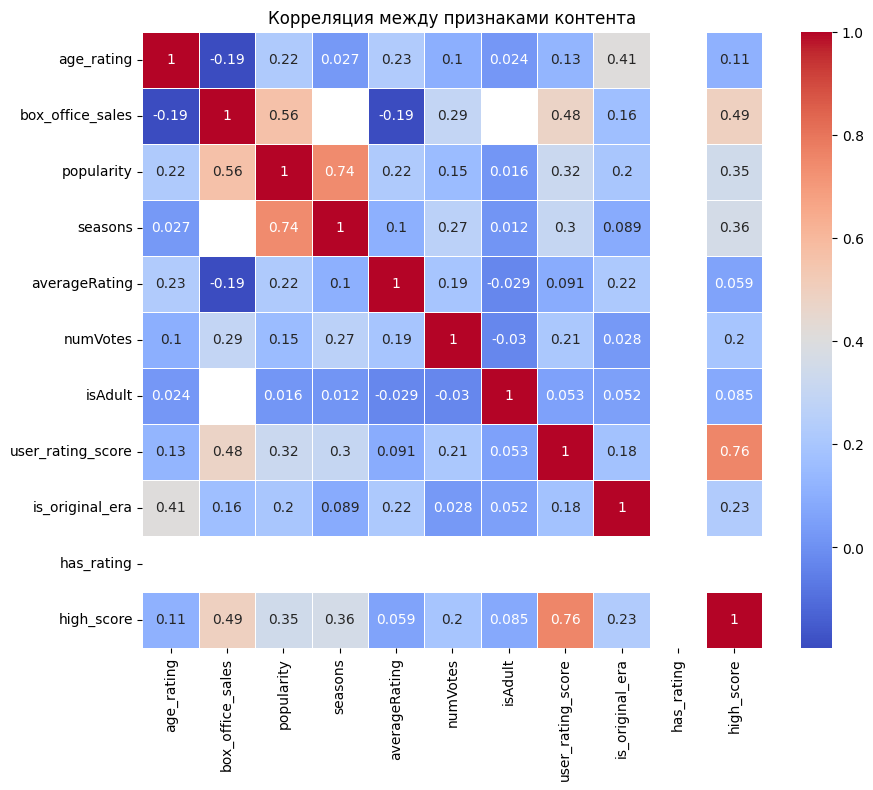

In [ ]:
correlation_matrix = observed.corr(numeric_only=True)
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Корреляция между признаками контента')
plt.show()

## Основные выводы

- Спрос на подростковый и взрослый контент. Наибольшее количество высоких оценок получают тайтлы для 14+ и 17+, что подтверждает высокий интерес к этим сегментам.
- Лучшие результаты в рекомендациях для взрослых и подростков. Рекомендации для этих сегментов более точные, в то время как детский контент требует дополнительной настройки.
- Новизна контента привлекает больше внимания. Релизы 2015-2017 годов показывают более высокие оценки.
- Проблема с контентом без оценок. Почти половина каталога не имеет отзывов, что требует использования других факторов, таких как жанр или возрастной рейтинг.
- Популярность - полезный сигнал. Популярные тайтлы имеют более высокие оценки, что делает популярность важным дополнительным фактором при ранжировании.
- Необходимость сегментации рекомендаций. Разные возрастные группы предпочитают разные жанры, требует персонализированного подхода к рекомендациям.
- Внешние метрики для фильмов. Метрики, такие как кассовые сборы и IMDb рейтинг, могут дополнительно улучшить рекомендации, особенно для фильмов с ограниченными данными.
- Качество данных - ключ к точности рекомендаций. Проблемы с дубликатами и неполными данными подчеркивают важность улучшения исходных данных для более точных выводов.

##**Дополнительные источники**

- https://ru.investing.com/equities/netflix,-inc.-earnings
- https://ir.netflix.net/financials/annual-reports-and-proxies/default.aspx
- https://www.goha.ru/u-netflix-vse-velikolepno-dohody-rastut-vmeste-s-bazoj-podpischikov-dB0EqZ
- https://www.kaggle.com/datasets/chasewillden/netflix-shows
- https://skillbox.ru/media/code/yazyk-razmetki-markdown-shpargalka-po-sintaksisu-s-primerami/?ysclid=mmtppm87lh186286440
-https://stackoverflow.com/questions/11700487/how-do-i-add-a-newline-in-a-markdown-table
- https://en.wikipedia.org/wiki/TV_Parental_Guidelines - возростные рейтинги
- https://plotly.com/python/ - графики plotly
- https://www.stuff.co.nz/technology/digital-living/91865403/netflixs-new-rating-system-is-confusing - "чужие рейтинги не используются"
- https://shazoo.ru/2017/04/05/50060/netflix-izmenit-sistemu-ocenok - про систему оценивания